Loan Approval Prediction using Machine Learning
Step 1: Importing the required libraries. We import the pandas, matplotlib,seaborn and sklearn libraries to handle data processing and visualization, and to conduct training and testing models.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier


In [ ]:
from google.colab import files
#uploaded = files.upload()

Step2 : Load and Explore the Dataset

In [ ]:
# Instructions for reading the file
df=pd.read_csv('bank-data.csv')
# Display the first 5 rows using the head instruction
print(df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [ ]:
# Display dataset dimensions (rows = customers, columns = features)
rows,columns=df.shape
print(f" customers number= {rows} ")
print(f" features number= {columns}")


 customers number= 981 
 features number= 13


In [ ]:
# Show column names
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [ ]:
# Show data types of each column
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [ ]:
# Display general info about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [ ]:
# Summary statistics for numeric columns only
print(df.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       981.000000         981.000000  954.000000        961.000000   
mean       5179.795107        1601.916330  142.511530        342.201873   
std        5695.104533        2718.772806   77.421743         65.100602   
min           0.000000           0.000000    9.000000          6.000000   
25%        2875.000000           0.000000  100.000000        360.000000   
50%        3800.000000        1110.000000  126.000000        360.000000   
75%        5516.000000        2365.000000  162.000000        360.000000   
max       81000.000000       41667.000000  700.000000        480.000000   

       Credit_History  
count      902.000000  
mean         0.835920  
std          0.370553  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [ ]:
# Count missing values per column
print(df.isnull().sum())


Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64


In [ ]:
# Percentage of missing values
print("\n Percentage of missing values:")
print((df.isnull().sum() / len(df)) * 100)


 Percentage of missing values:
Loan_ID               0.000000
Gender                2.446483
Married               0.305810
Dependents            2.548420
Education             0.000000
Self_Employed         5.606524
ApplicantIncome       0.000000
CoapplicantIncome     0.000000
LoanAmount            2.752294
Loan_Amount_Term      2.038736
Credit_History        8.053007
Property_Area         0.000000
Loan_Status          37.410805
dtype: float64


In [ ]:
# Count accepted vs rejected loans before processing
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


<Axes: xlabel='Loan_Status', ylabel='count'>

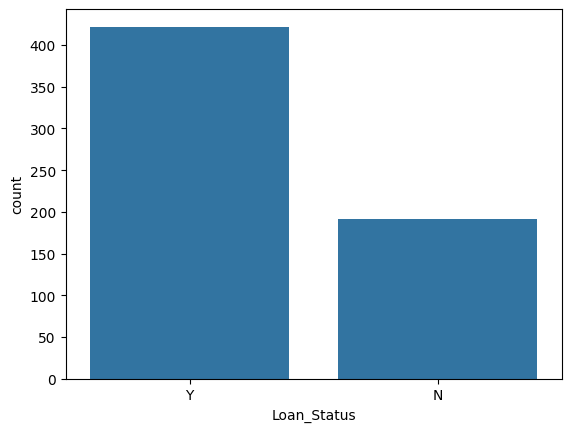

In [ ]:
# Visual representation of loan status before data processing

sns.countplot(x='Loan_Status', data=df)


**Step3 : Preprocessing Data**

In [ ]:
# Remove Loan_ID as it has no impact on prediction
df = df.drop('Loan_ID' , axis=1)

In [ ]:
# Replace "3+" with 3 to ensure numeric consistency for modeling
df["Dependents"] = df["Dependents"].replace("3+",3)

In [ ]:
# Split data into train and test based on availability of Loan_Status
train_data = df[df["Loan_Status"].notnull()].copy()
test_data = df[df["Loan_Status"].isnull()].copy()

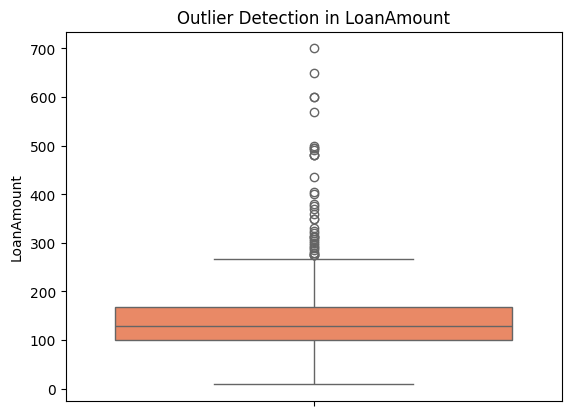

In [ ]:
# Check for outliers in LoanAmount
import matplotlib.pyplot as plt

sns.boxplot(y=train_data["LoanAmount"], color='coral')
plt.title('Outlier Detection in LoanAmount')
plt.show()

In [ ]:
print("--- Training Data Overview ---")
display(train_data.head(5))
display(train_data.tail(5))

print("\n--- Testing Data Overview ---")
display(test_data.head(5))
display(test_data.tail(5))

--- Training Data Overview ---


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N



--- Testing Data Overview ---


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
614,Male,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban,NaN
615,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Urban,NaN
616,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban,NaN
617,Male,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban,NaN
618,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban,NaN


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
976,Male,Yes,3,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
977,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
978,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
979,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN
980,Male,No,0,Graduate,Yes,9200,0.0,98.0,180.0,1.0,Rural,NaN


In [ ]:
# Define categorical columns
categorical_cols = ["Gender", "Married", "Dependents", "Self_Employed","Education","Property_Area"]

# Fill missing values in categorical columns using mode
for col in categorical_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])

# Fill missing values in binary column using mode
train_data["Credit_History"]= train_data["Credit_History"].fillna(train_data["Credit_History"].mode()[0])

# Fill missing values in numerical columns using median
train_data["LoanAmount"]= train_data["LoanAmount"].fillna(train_data["LoanAmount"].median())
train_data["Loan_Amount_Term"]= train_data["Loan_Amount_Term"].fillna(train_data["Loan_Amount_Term"].median())

In [ ]:
# Convert Dependents to numeric
train_data["Dependents"] = train_data["Dependents"].astype(int)

In [ ]:
# Drop Loan_Status from test_data
test_data = test_data.drop('Loan_Status',axis=1)

In [ ]:
# Apply preprocessing steps to test data using train data statistics
for col in categorical_cols:
    test_data[col] = test_data[col].fillna(train_data[col].mode()[0])

test_data["LoanAmount"] = test_data["LoanAmount"].fillna(train_data["LoanAmount"].median())
test_data["Loan_Amount_Term"] = test_data["Loan_Amount_Term"].fillna(train_data["Loan_Amount_Term"].median())
test_data["Credit_History"] = test_data["Credit_History"].fillna(train_data["Credit_History"].mode()[0])

In [ ]:
# Convert Dependents to numeric
test_data["Dependents"] = test_data["Dependents"].astype(int)

In [ ]:
# Final check to ensure no missing values and correct data types
print("Train missing:", train_data.isnull().sum().sum())
print("\nTrain types:\n", train_data.dtypes)

print("\nTest missing:", test_data.isnull().sum().sum())
print("\nTest types:\n", test_data.dtypes)


Train missing: 0

Train types:
 Gender                object
Married               object
Dependents             int64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Test missing: 0

Test types:
 Gender                object
Married               object
Dependents             int64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object


**Step 4 : Train data**

In [ ]:
# Separate features (X) and target variable (y)
X = train_data.drop("Loan_Status", axis=1)
y = train_data["Loan_Status"]

In [ ]:
# Convert categorical variables into dummy/indicator variables (One-Hot Encoding)
X = pd.get_dummies(X)
test_final = pd.get_dummies(test_data)

# Align the training and testing sets to ensure they have the exact same columns (fills missing columns in test with 0)
X, test_final = X.align(test_final, join='left', axis=1, fill_value=0)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model1 = LogisticRegression(max_iter=2000)
model1.fit(X_train_scaled, y_train)

# Prediction
y_pred1 = model1.predict(X_test_scaled)

# Accuracy %
acc1 = accuracy_score(y_test, y_pred1)
print(f"Logistic Regression Accuracy: {acc1 * 100:.2f}%")

Logistic Regression Accuracy: 78.86%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Model
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

# Prediction
y_pred2 = model2.predict(X_test)

# Accuracy %
acc2 = accuracy_score(y_test, y_pred2)
print(f"Decision Tree Accuracy: {acc2 * 100:.2f}%")

Decision Tree Accuracy: 73.98%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Model
model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train, y_train)

# Prediction
y_pred3 = model3.predict(X_test)

# Accuracy %
acc3 = accuracy_score(y_test, y_pred3)
print(f"Random Forest Accuracy: {acc3 * 100:.2f}%")

Random Forest Accuracy: 77.24%


In [ ]:
print("\n=== Model Comparison ===")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred1) * 100:.2f}%")
print(f"Decision Tree: {accuracy_score(y_test, y_pred2) * 100:.2f}%")
print(f"Random Forest: {accuracy_score(y_test, y_pred3) * 100:.2f}%")


=== Model Comparison ===
Logistic Regression: 78.86%
Decision Tree: 73.98%
Random Forest: 77.24%


5 Test Data & Results


In [ ]:
# extracting the detailed criteria for each model
from sklearn.metrics import classification_report, confusion_matrix
report1 = classification_report(y_test, y_pred1, output_dict=True)
report2 = classification_report(y_test, y_pred2, output_dict=True)
report3 = classification_report(y_test, y_pred3, output_dict=True)

In [ ]:
#constructing the comparative table that will be saved as the results file
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc1, acc2, acc3],
    'Precision (Class Y)': [report1['Y']['precision'], report2['Y']['precision'], report3['Y']['precision']],
    'Recall (Class Y)': [report1['Y']['recall'], report2['Y']['recall'], report3['Y']['recall']],
    'F1-Score (Class Y)': [report1['Y']['f1-score'], report2['Y']['f1-score'], report3['Y']['f1-score']]
})

In [ ]:
# automatically determine the best model
best_model_name = results_summary.iloc[results_summary['Accuracy'].idxmax()]['Model']
print(f"Best Model identified: {best_model_name}")

Best Model identified: {best_model_name}


In [ ]:
# save results file
results_summary.to_csv('Model_Performance_Results.csv', index=False)

In [ ]:
# Predicting test data based on the actual winner
if best_model_name == 'Logistic Regression':
    test_final_scaled = scaler.transform(test_final)
    final_predictions = model1.predict(test_final_scaled)

elif best_model_name == 'Decision Tree':
    final_predictions = model2.predict(test_final)

elif best_model_name == 'Random Forest':
    final_predictions = model3.predict(test_final)

In [ ]:
# save the final forecast file for the anonymous customers
final_complete_test = test_data.copy()
final_complete_test['Predicted_Loan_Status'] = final_predictions
final_complete_test.to_csv('Final_Predictions.csv', index=False)

**Step 6: Results Visualization**

/tmp/ipykernel_8627/3689151142.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_summary, palette=['#1A3A4D', '#547A82', '#A3B1B5'])


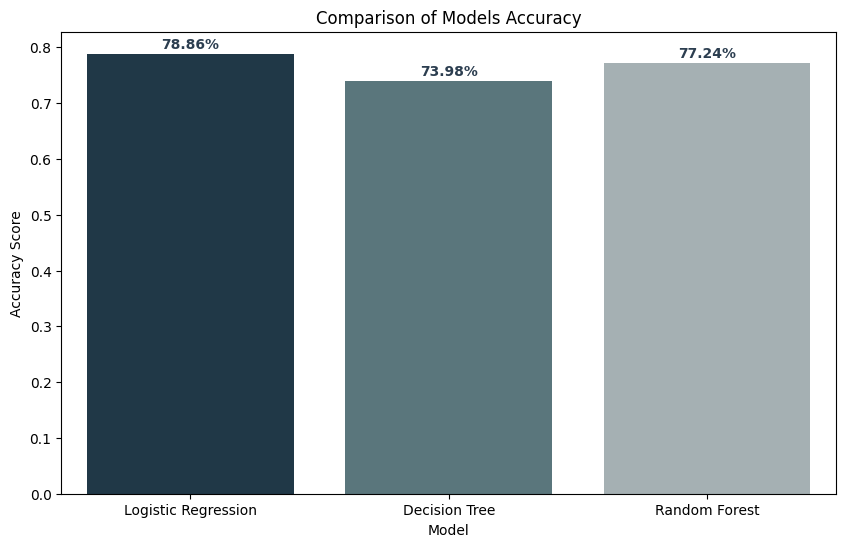

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# display models accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_summary, palette=['#1A3A4D', '#547A82', '#A3B1B5'])
# add the accuracy percentage labels on top of each bar
for i, v in enumerate(results_summary['Accuracy']):
    plt.text(i, v + 0.01, f'{v*100:.2f}%', ha='center', fontweight='bold', color='#2c3e50')

plt.title('Comparison of Models Accuracy')
plt.ylabel('Accuracy Score')
plt.show()

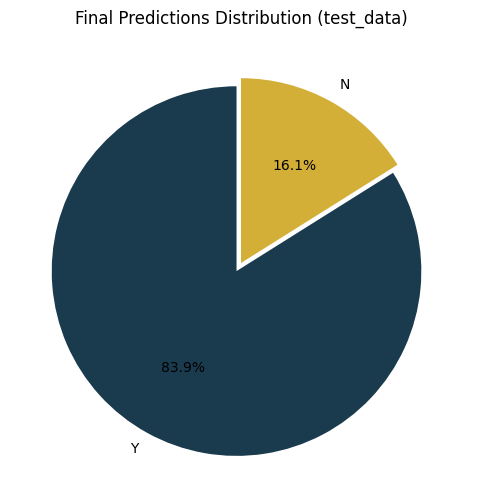

In [ ]:

# display Final Prediction Distribution (test_data)
plt.figure(figsize=(8, 6))
final_complete_test['Predicted_Loan_Status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#1A3A4D', '#D4AF37'],
    startangle=90,
    explode=(0.05, 0)
)

plt.title('Final Predictions Distribution (test_data)')
plt.ylabel('')
plt.show()